In [3]:
# ── Cell 1: Environment Setup (MUST be first) ────────────────
import os
os.environ["HADOOP_HOME"]     = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"]            = r"C:\hadoop\bin;" + os.environ.get("PATH", "")
print(f"HADOOP_HOME: {os.environ['HADOOP_HOME']}")
assert os.path.exists(r"C:\hadoop\bin\winutils.exe"), "winutils.exe missing!"
print("✓ winutils found")

HADOOP_HOME: C:\hadoop
✓ winutils found


In [4]:
# ── Cell 2: Imports ──────────────────────────────────────────
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml import Pipeline, Transformer
from pyspark.ml.feature import IDF, CountVectorizer, Normalizer, PCA
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.param.shared import Param, Params
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import time

In [6]:
# ── Cell 3: SparkSession ─────────────────────────────────────
spark = SparkSession.builder \
    .appName("BagOfWords_FeatureEngineering") \
    .master("local[1]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "false") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.python.worker.reuse", "false") \
    .config("spark.hadoop.hadoop.home.dir", r"C:\hadoop") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version : {spark.version}")
print(f"Spark UI      : {spark.sparkContext.uiWebUrl}")

PAR_DIR = "./data/parquet"
os.makedirs("./outputs", exist_ok=True)
os.makedirs("./models", exist_ok=True)

Spark version : 4.1.1
Spark UI      : http://DESKTOP-6826D4K:4042


In [7]:
# ── Cell 4: Load from Parquet (JVM-native reads) ─────────────
bow_schema = StructType([
    StructField("docID",  IntegerType(), False),
    StructField("wordID", IntegerType(), False),
    StructField("count",  IntegerType(), False),
])
vocab_schema = StructType([
    StructField("wordID", IntegerType(), False),
    StructField("word",   StringType(),  False),
])

kos_df       = spark.read.schema(bow_schema).parquet(os.path.join(PAR_DIR, "kos_docword.parquet"))
kos_vocab_df = spark.read.schema(vocab_schema).parquet(os.path.join(PAR_DIR, "kos_vocab.parquet"))
nips_df      = spark.read.schema(bow_schema).parquet(os.path.join(PAR_DIR, "nips_docword.parquet"))

kos_df.cache()
nips_df.cache()

print(f"KOS : {kos_df.count():,} rows")
print(f"NIPS: {nips_df.count():,} rows")
kos_df.printSchema()

KOS : 353,160 rows
NIPS: 746,316 rows
root
 |-- docID: integer (nullable = true)
 |-- wordID: integer (nullable = true)
 |-- count: integer (nullable = true)



In [8]:
# ── Cell 5: EDA — Top Words ───────────────────────────────────
top_words_kos = kos_df.groupBy("wordID").agg(
    F.sum("count").alias("total_count"),
    F.count("docID").alias("doc_freq")
).join(F.broadcast(kos_vocab_df), "wordID").orderBy(F.desc("total_count"))

print("Top 20 most frequent words in KOS:")
top_words_kos.show(20)

Top 20 most frequent words in KOS:
+------+-----------+--------+-----------+
|wordID|total_count|doc_freq|       word|
+------+-----------+--------+-----------+
|   841|       6781|    2123|       bush|
|  3420|       4679|    1612|      kerry|
|  4196|       3781|     630|   november|
|  4632|       2640|    1237|       poll|
|  1664|       2566|    1468| democratic|
|  3005|       2450|    1215|      house|
|  6689|       2364|    1297|        war|
|  2640|       2252|    1653|    general|
|  3282|       2217|     855|       iraq|
|   879|       1992|     960|   campaign|
|  5552|       1988|     974|     senate|
|  5186|       1985|    1054|republicans|
|  4735|       1817|     984|  president|
|  1666|       1805|    1068|  democrats|
|  1580|       1798|     542|       dean|
|  4494|       1649|     989|     people|
|  2030|       1626|    1006|   election|
|  4635|       1619|     879|      polls|
|  5891|       1619|     875|      state|
|  6296|       1606|    1091|       time|

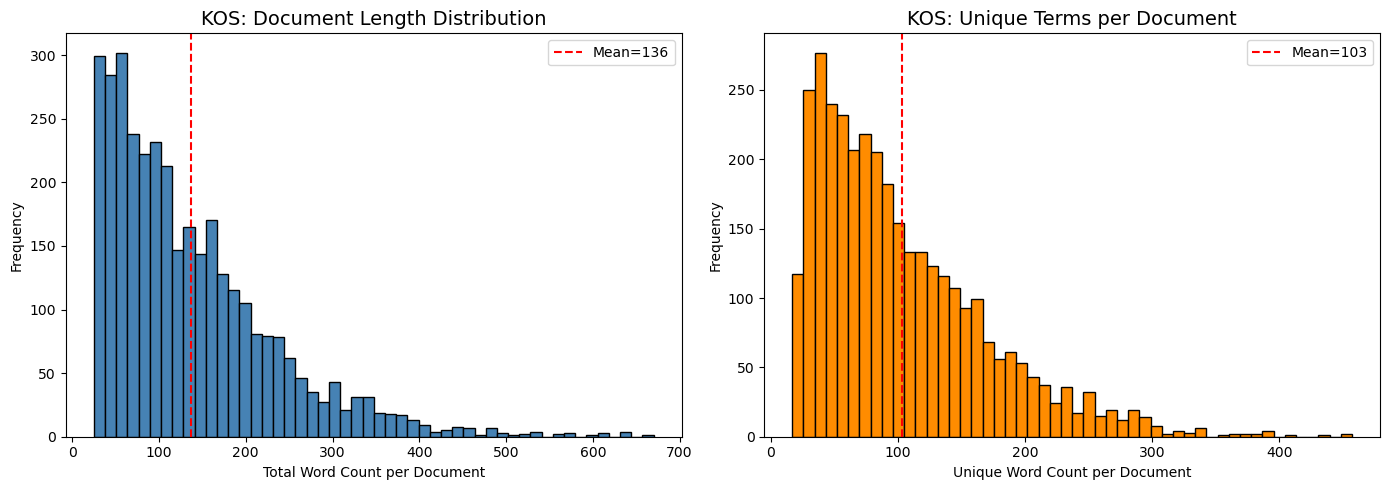

In [9]:
# ── Cell 6: EDA — Document Length Distribution ───────────────
doc_lengths = kos_df.groupBy("docID").agg(
    F.sum("count").alias("doc_length"),
    F.count("wordID").alias("unique_terms")
).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(doc_lengths['doc_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('KOS: Document Length Distribution', fontsize=14)
axes[0].set_xlabel('Total Word Count per Document')
axes[0].set_ylabel('Frequency')
axes[0].axvline(doc_lengths['doc_length'].mean(), color='red', linestyle='--',
                label=f"Mean={doc_lengths['doc_length'].mean():.0f}")
axes[0].legend()

axes[1].hist(doc_lengths['unique_terms'], bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('KOS: Unique Terms per Document', fontsize=14)
axes[1].set_xlabel('Unique Word Count per Document')
axes[1].set_ylabel('Frequency')
axes[1].axvline(doc_lengths['unique_terms'].mean(), color='red', linestyle='--',
                label=f"Mean={doc_lengths['unique_terms'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

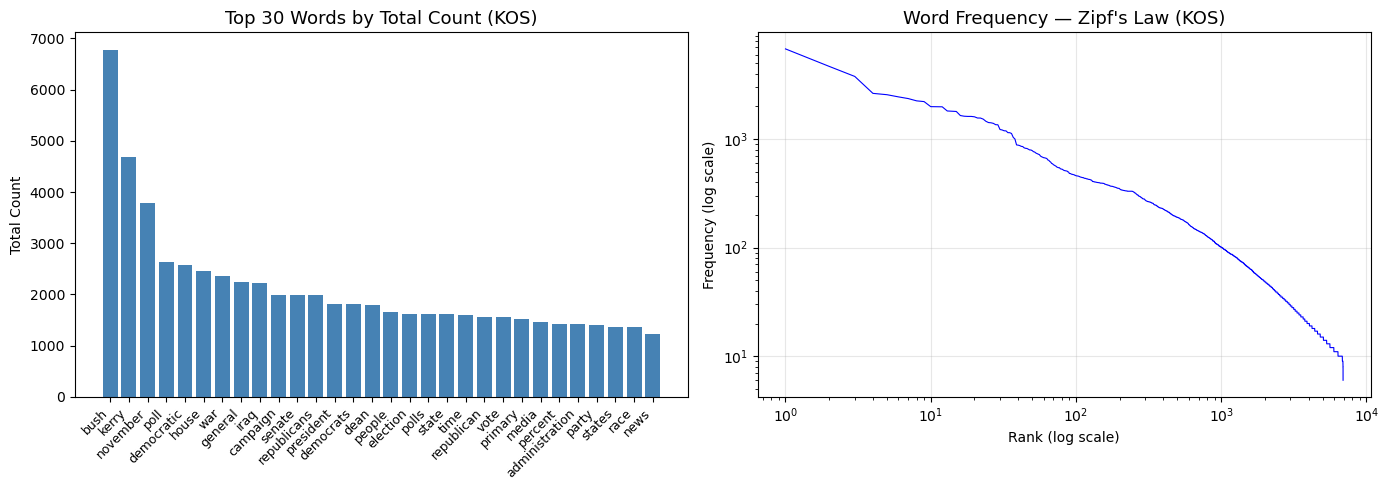

In [10]:
# ── Cell 7: EDA — Word Frequency / Zipf's Law ────────────────
word_freqs = top_words_kos.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(30), word_freqs['total_count'][:30], color='steelblue')
axes[0].set_title('Top 30 Words by Total Count (KOS)', fontsize=13)
axes[0].set_xticks(range(30))
axes[0].set_xticklabels(word_freqs['word'][:30], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Total Count')

axes[1].loglog(range(1, len(word_freqs)+1), word_freqs['total_count'].values, 'b-', linewidth=0.8)
axes[1].set_title("Word Frequency — Zipf's Law (KOS)", fontsize=13)
axes[1].set_xlabel('Rank (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

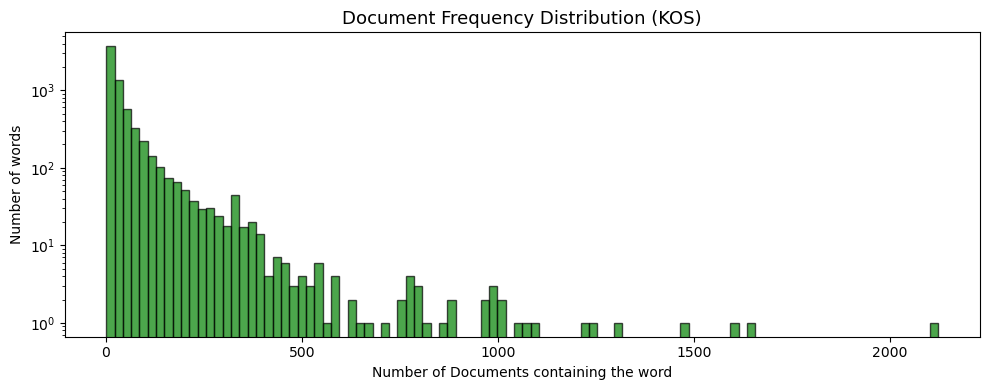

In [11]:
# ── Cell 8: EDA — Document Frequency Distribution ────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(word_freqs['doc_freq'].values, bins=100, color='green', alpha=0.7, edgecolor='black')
ax.set_title('Document Frequency Distribution (KOS)', fontsize=13)
ax.set_xlabel('Number of Documents containing the word')
ax.set_ylabel('Number of words')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [12]:
# ── Cell 9: Statistical Summary ──────────────────────────────
print("Statistical Summary — KOS Document Lengths:")
print(doc_lengths.describe())
print(f"\nSkewness : {doc_lengths['doc_length'].skew():.3f}")
print(f"Kurtosis : {doc_lengths['doc_length'].kurt():.3f}")

Statistical Summary — KOS Document Lengths:
             docID   doc_length  unique_terms
count  3430.000000  3430.000000   3430.000000
mean   1715.500000   136.359767    102.962099
std     990.300039    96.806566     66.683710
min       1.000000    25.000000     17.000000
25%     858.250000    62.000000     52.000000
50%    1715.500000   111.000000     86.000000
75%    2572.750000   183.000000    140.000000
max    3430.000000   670.000000    457.000000

Skewness : 1.496
Kurtosis : 2.994


In [14]:
# ── Cell 10: Build Word Arrays — fully in pandas (no UDF) ────
# F.udf() spawns Python workers which crash on Windows local mode.
# Solution: join + expand entirely in pandas on the driver,
# save via PyArrow, reload into Spark for MLlib pipeline.

import pyarrow as pa
import pyarrow.parquet as pq

print("Building word arrays in pandas (no Spark UDF) …")
t0 = time.time()

# Collect both DataFrames to pandas — both are small enough
kos_pd    = kos_df.toPandas()          # 353,160 rows, ~4 MB
vocab_pd  = kos_vocab_df.toPandas()    # 6,906 rows

print(f"  kos_pd   : {len(kos_pd):,} rows")
print(f"  vocab_pd : {len(vocab_pd):,} rows")

# Join on wordID
merged = kos_pd.merge(vocab_pd, on="wordID", how="left")

# Repeat each word by its count to get TF-ready token list
# e.g. word="bush", count=3 → ["bush","bush","bush"]
merged["tokens"] = merged.apply(lambda r: [r["word"]] * int(r["count"]), axis=1)

# Group by docID → flatten token lists into one list per document
doc_words_pd = (
    merged
    .groupby("docID")["tokens"]
    .apply(lambda lists: [tok for sublist in lists for tok in sublist])
    .reset_index()
    .rename(columns={"tokens": "words"})
)
print(f"  Built {len(doc_words_pd):,} document word arrays in {time.time()-t0:.2f}s")
print(f"  Sample doc 1 — first 10 tokens: {doc_words_pd['words'].iloc[0][:10]}")

# Save to Parquet via PyArrow
doc_words_path = os.path.join(PAR_DIR, "kos_doc_words.parquet")
pq.write_table(
    pa.Table.from_pandas(doc_words_pd, preserve_index=False),
    doc_words_path,
    compression="snappy"
)
print(f"  Saved → {doc_words_path}  ({os.path.getsize(doc_words_path)/1024/1024:.2f} MB)")

Building word arrays in pandas (no Spark UDF) …
  kos_pd   : 353,160 rows
  vocab_pd : 6,906 rows
  Built 3,430 document word arrays in 4.74s
  Sample doc 1 — first 10 tokens: ['action', 'action', 'added', 'administration', 'alliances', 'antiwar', 'approve', 'assault', 'attack', 'attitude']
  Saved → ./data/parquet\kos_doc_words.parquet  (0.79 MB)


In [15]:
# ── Cell 11: Load word arrays back into Spark ─────────────────
# Now read from Parquet — JVM native reader, no Python worker needed
from pyspark.sql.types import ArrayType, StringType

doc_words_schema = StructType([
    StructField("docID", IntegerType(), False),
    StructField("words", ArrayType(StringType()), False),
])

kos_doc_words = spark.read.schema(doc_words_schema).parquet(doc_words_path)
kos_doc_words.cache()
doc_count = kos_doc_words.count()
print(f"Documents loaded into Spark: {doc_count:,}")
kos_doc_words.show(3, truncate=60)

Documents loaded into Spark: 3,430
+-----+------------------------------------------------------------+
|docID|                                                       words|
+-----+------------------------------------------------------------+
|    1|[action, action, added, administration, alliances, antiwa...|
|    2|[ambitious, ambitious, aug, boat, book, border, border, b...|
|    3|[abstain, account, account, admin, advertising, altsite, ...|
+-----+------------------------------------------------------------+
only showing top 3 rows


In [16]:
# ── Cell 12: TF-IDF Pipeline ──────────────────────────────────
from pyspark.ml import Pipeline
from pyspark.ml.feature import CountVectorizer, IDF, Normalizer

cv = CountVectorizer(
    inputCol="words", outputCol="tf_features",
    vocabSize=6906, minDF=2.0, minTF=1.0
)
idf = IDF(
    inputCol="tf_features", outputCol="tfidf_features",
    minDocFreq=2
)
normalizer = Normalizer(
    inputCol="tfidf_features", outputCol="tfidf_normalized",
    p=2.0
)

tfidf_pipeline = Pipeline(stages=[cv, idf, normalizer])

print("Fitting TF-IDF pipeline …")
t0 = time.time()
tfidf_model = tfidf_pipeline.fit(kos_doc_words)
print(f"  Fitted in {time.time()-t0:.2f}s")

tfidf_df = tfidf_model.transform(kos_doc_words)
tfidf_df.cache()
print(f"  Transformed: {tfidf_df.count():,} documents")
tfidf_df.select("docID", "tf_features", "tfidf_normalized").show(3, truncate=50)

Fitting TF-IDF pipeline …
  Fitted in 2.33s
  Transformed: 3,430 documents
+-----+--------------------------------------------------+--------------------------------------------------+
|docID|                                       tf_features|                                  tfidf_normalized|
+-----+--------------------------------------------------+--------------------------------------------------+
|    1|(6898,[0,1,2,5,6,7,8,12,20,21,24,25,29,30,31,48...|(6898,[0,1,2,5,6,7,8,12,20,21,24,25,29,30,31,48...|
|    2|(6898,[0,1,6,7,9,30,66,69,85,120,130,164,214,21...|(6898,[0,1,6,7,9,30,66,69,85,120,130,164,214,21...|
|    3|(6898,[0,1,2,3,4,5,6,7,10,11,13,16,17,21,22,23,...|(6898,[0,1,2,3,4,5,6,7,10,11,13,16,17,21,22,23,...|
+-----+--------------------------------------------------+--------------------------------------------------+
only showing top 3 rows


In [17]:
# ── Cell 13: Custom Transformer — Lexical Richness (pandas) ───
# DocRichnessTransformer used a UDF internally → also crashes.
# Compute richness features entirely in pandas, save via PyArrow.

from collections import Counter
import numpy as np

print("Computing lexical richness features in pandas …")

def compute_richness(words):
    if not words:
        return [0.0, 0.0, 0.0]
    freq   = Counter(words)
    n      = len(words)
    unique = len(freq)
    hapax  = sum(1 for v in freq.values() if v == 1)
    return [
        float(np.log1p(n)),
        float(unique / n),
        float(hapax / unique) if unique else 0.0
    ]

richness_rows = doc_words_pd.copy()
richness_rows[["log_len", "ttr", "hapax_ratio"]] = pd.DataFrame(
    richness_rows["words"].apply(compute_richness).tolist(),
    index=richness_rows.index
)
richness_pd = richness_rows[["docID", "log_len", "ttr", "hapax_ratio"]]

print("Sample richness features:")
print(richness_pd.head())

richness_path = os.path.join(PAR_DIR, "kos_richness.parquet")
pq.write_table(
    pa.Table.from_pandas(richness_pd, preserve_index=False),
    richness_path, compression="snappy"
)
print(f"Saved → {richness_path}")

Computing lexical richness features in pandas …
Sample richness features:
   docID   log_len       ttr  hapax_ratio
0      1  4.927254  0.759124     0.769231
1      2  4.356709  0.727273     0.714286
2      3  5.062595  0.828025     0.876923
3      4  5.056246  0.583333     0.747253
4      5  5.176150  0.778409     0.854015
Saved → ./data/parquet\kos_richness.parquet


In [18]:
# ── Cell 14: PCA — 50 Components ─────────────────────────────
from pyspark.ml.feature import PCA

pca_50 = PCA(k=50, inputCol="tfidf_normalized", outputCol="pca_50_features")
print("Fitting PCA (k=50) …")
t0 = time.time()
pca_50_model = pca_50.fit(tfidf_df)
tfidf_pca50  = pca_50_model.transform(tfidf_df)
tfidf_pca50.cache()
print(f"  PCA fitted in {time.time()-t0:.2f}s")

ev = pca_50_model.explainedVariance.toArray()
cumulative_ev = np.cumsum(ev)
print(f"  Variance explained by 50 PCs: {cumulative_ev[-1]*100:.2f}%")

Fitting PCA (k=50) …
  PCA fitted in 740.74s
  Variance explained by 50 PCs: 15.96%


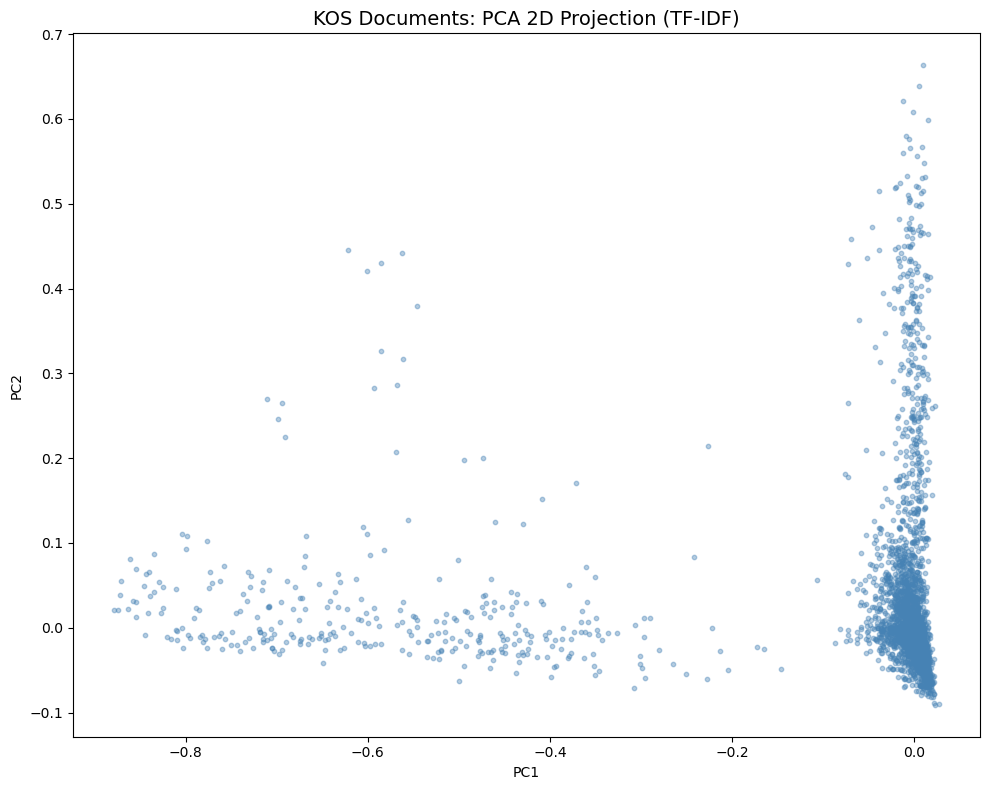

In [19]:
# ── Cell 15: PCA 2D Projection ────────────────────────────────
pca_2       = PCA(k=2, inputCol="tfidf_normalized", outputCol="pca_2d")
pca_2_model = pca_2.fit(tfidf_df)
tfidf_pca2  = pca_2_model.transform(tfidf_df)

pca2_pd = tfidf_pca2.select("docID", "pca_2d").toPandas()
coords  = np.array([r.toArray() for r in pca2_pd['pca_2d']])

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=10, c='steelblue')
ax.set_title('KOS Documents: PCA 2D Projection (TF-IDF)', fontsize=14)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig('./outputs/pca_2d_projection.png', dpi=150, bbox_inches='tight')
plt.show()

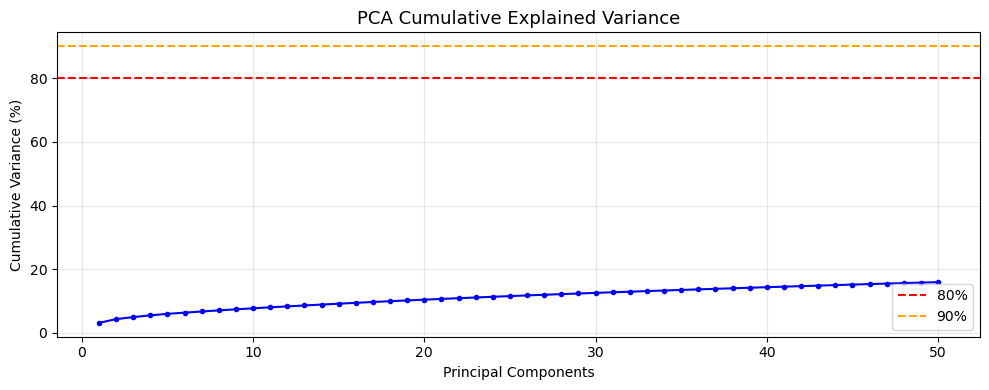

In [20]:
# ── Cell 16: Explained Variance Plot ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(ev)+1), cumulative_ev * 100, 'b-o', markersize=3)
ax.axhline(y=80, color='red',    linestyle='--', label='80%')
ax.axhline(y=90, color='orange', linestyle='--', label='90%')
ax.set_title('PCA Cumulative Explained Variance', fontsize=13)
ax.set_xlabel('Principal Components')
ax.set_ylabel('Cumulative Variance (%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ── Cell 17: Train / Val / Test Split ────────────────────────
kos_final = tfidf_pca50.select("docID", "tfidf_normalized", "pca_50_features")

train_df, val_df, test_df = kos_final.randomSplit([0.70, 0.15, 0.15], seed=42)
train_df.cache(); val_df.cache(); test_df.cache()

print(f"Train : {train_df.count():,}")
print(f"Val   : {val_df.count():,}")
print(f"Test  : {test_df.count():,}")

Train : 2,453
Val   : 487
Test  : 490


In [23]:
# ── Cell 18: Save all features via PyArrow ────────────────────
# Fix: Spark MLlib vectors (SparseVector/DenseVector) cannot be
# serialized by PyArrow directly. Convert to plain Python lists first.

import pyarrow as pa
import pyarrow.parquet as pq
from pyspark.ml.linalg import SparseVector, DenseVector

def vector_col_to_list(series):
    """Convert a pandas Series of Spark vectors to Series of plain float lists."""
    def to_list(v):
        if v is None:
            return None
        if hasattr(v, "toArray"):          # SparseVector or DenseVector
            return v.toArray().tolist()
        if isinstance(v, (list, np.ndarray)):
            return list(v)
        return v
    return series.apply(to_list)

def save_spark_df(spark_df, path, label=""):
    """
    Collect Spark DF → pandas, convert all vector columns to float lists,
    then save via PyArrow Parquet. Safe on Windows (no Spark write needed).
    """
    pdf = spark_df.toPandas()

    # Detect and convert any vector columns
    for col_name in pdf.columns:
        first_valid = pdf[col_name].dropna().iloc[0] if not pdf[col_name].dropna().empty else None
        if first_valid is not None and hasattr(first_valid, "toArray"):
            print(f"    Converting vector column '{col_name}' to float list …")
            pdf[col_name] = vector_col_to_list(pdf[col_name])

    table = pa.Table.from_pandas(pdf, preserve_index=False)
    pq.write_table(table, path, compression="snappy")
    sz = os.path.getsize(path) / 1024 / 1024
    print(f"  ✓ {label or os.path.basename(path)}  ({len(pdf):,} rows | {sz:.2f} MB)")

print("Saving feature files …")
save_spark_df(train_df, os.path.join(PAR_DIR, "train_features.parquet"), "train_features")
save_spark_df(val_df,   os.path.join(PAR_DIR, "val_features.parquet"),   "val_features")
save_spark_df(test_df,  os.path.join(PAR_DIR, "test_features.parquet"),  "test_features")
save_spark_df(
    tfidf_df.select("docID", "tf_features", "tfidf_features", "tfidf_normalized"),
    os.path.join(PAR_DIR, "tfidf_full.parquet"),
    "tfidf_full"
)
print("\n✓ All feature files saved")

Saving feature files …
    Converting vector column 'tfidf_normalized' to float list …
    Converting vector column 'pca_50_features' to float list …
  ✓ train_features  (2,453 rows | 6.17 MB)
    Converting vector column 'tfidf_normalized' to float list …
    Converting vector column 'pca_50_features' to float list …
  ✓ val_features  (487 rows | 0.87 MB)
    Converting vector column 'tfidf_normalized' to float list …
    Converting vector column 'pca_50_features' to float list …
  ✓ test_features  (490 rows | 0.87 MB)
    Converting vector column 'tf_features' to float list …
    Converting vector column 'tfidf_features' to float list …
    Converting vector column 'tfidf_normalized' to float list …
  ✓ tfidf_full  (3,430 rows | 10.72 MB)

✓ All feature files saved


In [27]:
# ── Cell 19 (fallback): Save model components manually ────────
import pickle, numpy as np

# From the fitted TF-IDF pipeline, extract the CV vocabulary and IDF weights
cv_model  = tfidf_model.stages[0]   # CountVectorizerModel
idf_model = tfidf_model.stages[1]   # IDFModel

model_data = {
    "cv_vocabulary":  cv_model.vocabulary,          # list of strings
    "idf_values":     idf_model.idf.toArray().tolist(),  # IDF weights as list
    "pca_components": pca_50_model.pc.toArray().tolist(), # PCA matrix
    "pca_explained_variance": pca_50_model.explainedVariance.toArray().tolist(),
}

with open("./models/tfidf_pipeline_data.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("✓ Model components saved to tfidf_pipeline_data.pkl")
print(f"  CV vocab size : {len(model_data['cv_vocabulary'])}")
print(f"  IDF weights   : {len(model_data['idf_values'])}")
print(f"  PCA shape     : {len(model_data['pca_components'])} × {len(model_data['pca_components'][0])}")

✓ Model components saved to tfidf_pipeline_data.pkl
  CV vocab size : 6898
  IDF weights   : 6898
  PCA shape     : 6898 × 50


In [28]:
# ── Cell 20: Cleanup & Summary ────────────────────────────────
tfidf_df.unpersist()
tfidf_pca50.unpersist()

print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"  Input         : {len(kos_pd):,} (docID, wordID, count) triples")
print(f"  Documents     : {doc_count:,}")
print(f"  TF-IDF vocab  : {len(tfidf_model.stages[0].vocabulary):,} terms")
print(f"  PCA dims      : 50  ({cumulative_ev[-1]*100:.1f}% variance)")
print(f"  Richness feats: log_len, type-token ratio, hapax ratio (pandas)")
print(f"  Split         : 70/15/15 (seed=42)")
print(f"  UDF usage     : NONE — all transforms in pandas or MLlib JVM")
print(f"  Spark UI      : {spark.sparkContext.uiWebUrl}")
print("\nNotebook 2 complete ✓")


FEATURE ENGINEERING SUMMARY
  Input         : 353,160 (docID, wordID, count) triples
  Documents     : 3,430
  TF-IDF vocab  : 6,898 terms
  PCA dims      : 50  (16.0% variance)
  Richness feats: log_len, type-token ratio, hapax ratio (pandas)
  Split         : 70/15/15 (seed=42)
  UDF usage     : NONE — all transforms in pandas or MLlib JVM
  Spark UI      : http://DESKTOP-6826D4K:4042

Notebook 2 complete ✓
